Loading real data from CSV...
Initialized tuningPlotter with topic: Parameter Tuning Progress, ax_real_name: Real Velocity Data, ax_try_name: Simulated Velocity Data
Better or Accepted new score: 6.680975 at iteration 0
Iter 0: New Best Score Found: 6.680975
Best Parameters: {'B': 0.09951723265682996, 'B_0': 0.100361675958547, 'mu_rolling': 0.005060135003283024}
Better or Accepted new score: 6.679765 at iteration 1
Iter 1: New Best Score Found: 6.679765
Best Parameters: {'B': 0.09906332882423986, 'B_0': 0.10058228008483477, 'mu_rolling': 0.005047849854293843}
Better or Accepted new score: 6.689498 at iteration 2
Better or Accepted new score: 6.697935 at iteration 3
Better or Accepted new score: 6.711101 at iteration 4
Better or Accepted new score: 6.723367 at iteration 5
Better or Accepted new score: 6.696047 at iteration 6
Better or Accepted new score: 6.677801 at iteration 7
Iter 7: New Best Score Found: 6.677801
Best Parameters: {'B': 0.09824717378177528, 'B_0': 0.10166046342746453,

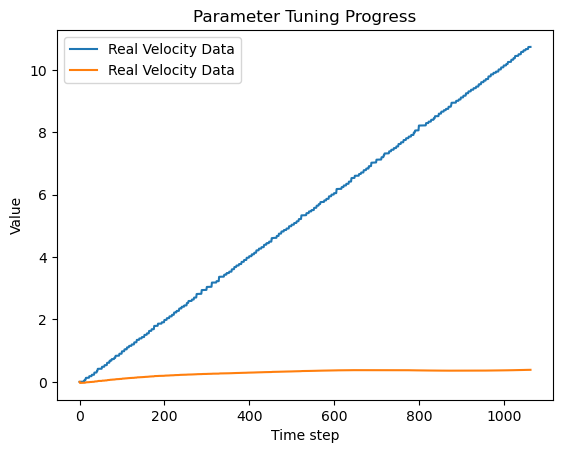

In [1]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 10),
        control_mode=CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.5,
        desired_position=0.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")

mode_segments = parse_mixed_csv("c:\\Users\\labuser\\Desktop\\unicycle_project_umich\\LOGS\\ValidLogs\\log_2026-04-01_14-20-46.533.csv")
data = None
for item in mode_segments:
    if item['mode'] == 'velocity':
        data = item['data'] # the last veloicity 

if data is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No velocity data found in the CSV file.")

realdata = getVelocityFromData(data)

def penaltyFunc(resultStorage):
    error = 0.0

    if realdata is None or len(realdata) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[1]  #  second column is velocity

    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    for item in realdata:
        time = item[0]
        real_vel = item[1]
        closest_time = min(numeric_results, key=lambda x: abs(x[0] - time))
        sim_vel = closest_time[1]
        # calculate the squared error
        error += (real_vel - sim_vel) ** 2
    
    #print(f"Current penalty (MSE): {error / len(realdata)}")
    return error/ len(realdata)



best_params = tune_parameters(paramDict = {"B": 0.1, "B_0": 0.1, "mu_rolling": 0.005},
                                simulation=simulate,
                                realdata=realdata,
                                ax_real_name="Real Velocity Data",
                                ax_try_name="Simulated Velocity Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 1, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 1
                                )
print("Best parameters found:", best_params)